In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.datasets import Omniglot
import matplotlib.pyplot as plt
import numpy as np


transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1.0 - x)
])

print("Downloading and loading Omniglot dataset...")
train_dataset = Omniglot(root='./data', background=True, download=True, transform=transform)
test_dataset = Omniglot(root='./data', background=False, download=True, transform=transform)

print(f"Total training samples: {len(train_dataset)}")
print(f"Total testing samples: {len(test_dataset)}")

100%|██████████| 9.46M/9.46M [00:00<00:00, 466MB/s]
100%|██████████| 6.46M/6.46M [00:00<00:00, 363MB/s]


Total training samples: 19280
Total testing samples: 13180


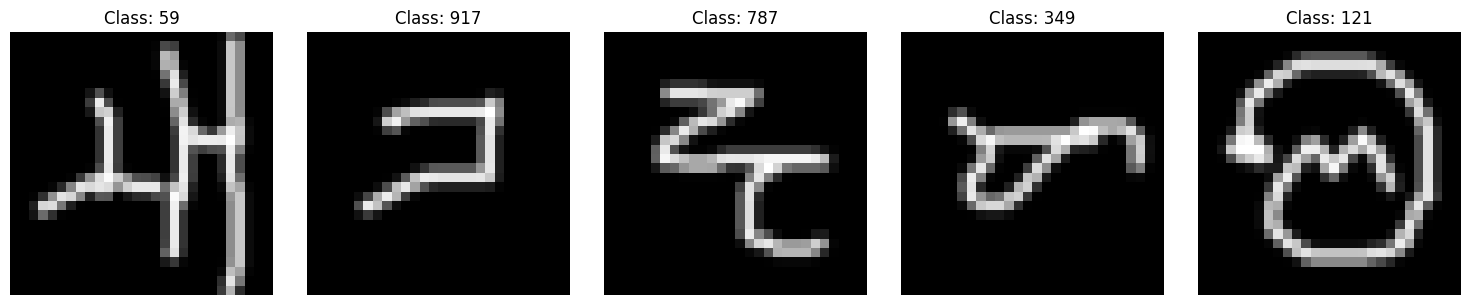

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img, label = train_dataset[np.random.randint(len(train_dataset))]

    axes[i].imshow(img.squeeze().numpy(), cmap='gray')
    axes[i].set_title(f"Class: {label}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [3]:
class ProtoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.MaxPool2d(2)
            )

        self.encoder = nn.Sequential(
            conv_block(1, 64),
            conv_block(64, 64),
            conv_block(64, 64),
            conv_block(64, 64)
        )

    def forward(self, x):
        return self.encoder(x).view(x.size(0), -1)

In [4]:
def get_random_episode(dataset, labels, n_way, k_shot, q_query, device='cuda'):

    classes = np.unique(labels)
    sampled_classes = np.random.choice(classes, n_way, replace=False)

    images = []
    for c in sampled_classes:
        indices = np.where(labels == c)[0]
        selected = np.random.choice(indices, k_shot + q_query, replace=False)
        for idx in selected:
            img, _ = dataset[idx]
            images.append(img)

    return torch.stack(images).to(device)

In [5]:
def compute_proto_loss(model, episode_data, n_way, k_shot, q_query):

    embeddings = model(episode_data)
    feat_dim = embeddings.size(-1)

    embeddings = embeddings.view(n_way, k_shot + q_query, feat_dim)

    support = embeddings[:, :k_shot, :]
    query = embeddings[:, k_shot:, :].contiguous().view(n_way * q_query, feat_dim)

    prototypes = support.mean(dim=1)

    dists = torch.cdist(query, prototypes)

    labels = torch.arange(n_way, device=episode_data.device).repeat_interleave(q_query)

    log_p = F.log_softmax(-dists, dim=1)
    loss = -log_p.gather(1, labels.unsqueeze(1)).squeeze().mean()

    _, preds = log_p.max(1)
    acc = (preds == labels).float().mean()

    return loss, acc

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ProtoEncoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_labels = np.array([sample[1] for sample in train_dataset._flat_character_images])
test_labels = np.array([sample[1] for sample in test_dataset._flat_character_images])

N_WAY = 5
K_SHOT = 1
Q_QUERY = 5
NUM_EPISODES = 100

print("\n================ Starting ProtoNet Training ================")
model.train()
for episode in range(1, NUM_EPISODES + 1):
    episode_images = get_random_episode(train_dataset, train_labels, N_WAY, K_SHOT, Q_QUERY, device)

    optimizer.zero_grad()
    loss, acc = compute_proto_loss(model, episode_images, N_WAY, K_SHOT, Q_QUERY)
    loss.backward()
    optimizer.step()

    if episode % 20 == 0:
        print(f"Episode [{episode:03d}/{NUM_EPISODES}] | Train Loss: {loss.item():.4f} | Train Acc: {acc.item()*100:.2f}%")



================ Starting ProtoNet Training ================
Episode [020/100] | Train Loss: 0.7541 | Train Acc: 64.00%
Episode [040/100] | Train Loss: 0.6358 | Train Acc: 80.00%
Episode [060/100] | Train Loss: 0.4183 | Train Acc: 92.00%
Episode [080/100] | Train Loss: 0.2989 | Train Acc: 92.00%
Episode [100/100] | Train Loss: 0.1702 | Train Acc: 96.00%


In [7]:
print("\n================ Evaluating on Unseen Test Classes ================")
model.eval()

test_accs_1shot = []
with torch.no_grad():
    for _ in range(50):
        test_images = get_random_episode(test_dataset, test_labels, n_way=5, k_shot=1, q_query=5, device=device)
        _, acc = compute_proto_loss(model, test_images, n_way=5, k_shot=1, q_query=5)
        test_accs_1shot.append(acc.item())

print(f"Mean Test Accuracy (5-way 1-shot): {np.mean(test_accs_1shot)*100:.2f}%")

test_accs_5shot = []
with torch.no_grad():
    for _ in range(50):
        test_images = get_random_episode(test_dataset, test_labels, n_way=5, k_shot=5, q_query=5, device=device)
        _, acc = compute_proto_loss(model, test_images, n_way=5, k_shot=5, q_query=5)
        test_accs_5shot.append(acc.item())

print(f"Mean Test Accuracy (5-way 5-shot): {np.mean(test_accs_5shot)*100:.2f}%")


================ Evaluating on Unseen Test Classes ================
Mean Test Accuracy (5-way 1-shot): 86.40%
Mean Test Accuracy (5-way 5-shot): 93.12%


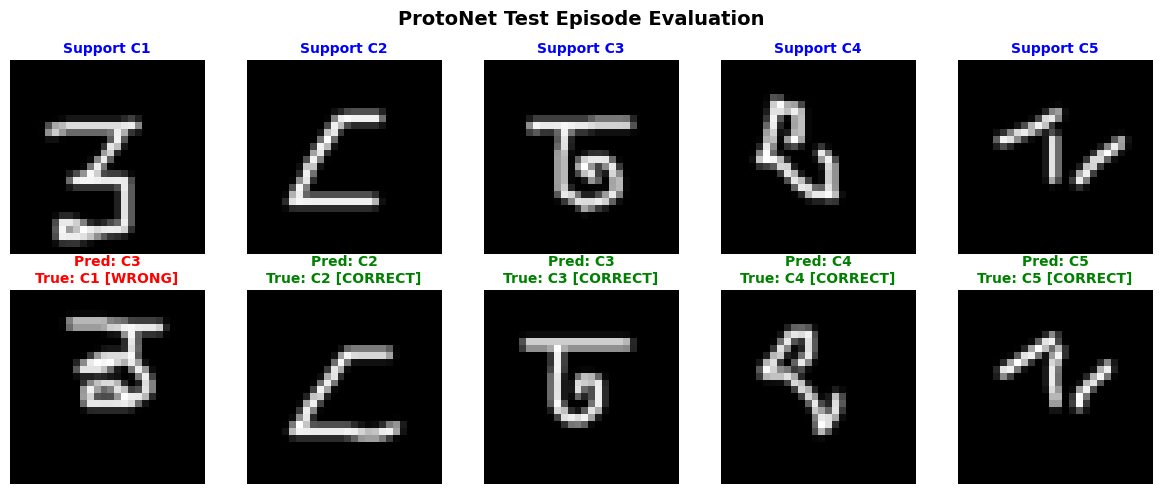

In [8]:
def visualize_test_predictions(model, dataset, labels, device='cuda'):
    model.eval()
    n_way = 5
    k_shot = 1
    q_query = 1


    classes = np.unique(labels)
    sampled_classes = np.random.choice(classes, n_way, replace=False)

    support_imgs, query_imgs, query_gt = [], [], []

    for class_idx, c in enumerate(sampled_classes):
        indices = np.where(labels == c)[0]
        selected = np.random.choice(indices, k_shot + q_query, replace=False)

        s_img, _ = dataset[selected[0]]
        support_imgs.append(s_img)

        q_img, _ = dataset[selected[1]]
        query_imgs.append(q_img)
        query_gt.append(class_idx)

    support_tensor = torch.stack(support_imgs).to(device)
    query_tensor = torch.stack(query_imgs).to(device)

    with torch.no_grad():
        s_emb = model(support_tensor)
        q_emb = model(query_tensor)

        dists = torch.cdist(q_emb, s_emb)
        preds = torch.argmin(dists, dim=1).cpu().numpy()

    fig, axes = plt.subplots(2, n_way, figsize=(12, 5))
    fig.suptitle("ProtoNet Test Episode Evaluation", fontsize=14, fontweight='bold')

    for i in range(n_way):
        axes[0, i].imshow(support_imgs[i].squeeze(), cmap='gray')
        axes[0, i].set_title(f"Support C{i+1}", fontsize=10, color='blue', fontweight='bold')
        axes[0, i].axis('off')

    for i in range(n_way):
        pred_class = preds[i]
        true_class = query_gt[i]
        is_correct = (pred_class == true_class)

        color = 'green' if is_correct else 'red'
        status = "CORRECT" if is_correct else "WRONG"

        axes[1, i].imshow(query_imgs[i].squeeze(), cmap='gray')
        axes[1, i].set_title(f"Pred: C{pred_class+1}\nTrue: C{true_class+1} [{status}]",
                            fontsize=10, color=color, fontweight='bold')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

visualize_test_predictions(model, test_dataset, test_labels, device)

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1.0 - x)
])

test_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1.0 - x)
])

In [10]:
class ResBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        ) if in_channels != out_channels else nn.Identity()

        self.pool = nn.MaxPool2d(2)
        self.relu = nn.LeakyReLU(0.1)

    def forward(self, x):
        res = self.shortcut(x)

        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))

        x = x + res
        x = self.relu(x)
        x = self.pool(x)
        return x

In [11]:
class ResNet12Encoder(nn.Module):

    def __init__(self, in_channels=1):
        super().__init__()
        self.layer1 = ResBlock(in_channels, 64)   # 28x28 -> 14x14
        self.layer2 = ResBlock(64, 128)          # 14x14 -> 7x7
        self.layer3 = ResBlock(128, 256)         # 7x7 -> 3x3
        self.layer4 = ResBlock(256, 512)         # 3x3 -> 1x1
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        return x.view(x.size(0), -1)

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNet12Encoder(in_channels=1).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=150, gamma=0.5)

train_labels = np.array([sample[1] for sample in train_dataset._flat_character_images])
test_labels = np.array([sample[1] for sample in test_dataset._flat_character_images])

N_WAY_TRAIN = 20
K_SHOT_TRAIN = 1
Q_QUERY_TRAIN = 5
NUM_EPISODES = 500

print("\n================ Starting ResNet-12 ProtoNet Training (20-way) ================")
model.train()
for episode in range(1, NUM_EPISODES + 1):
    episode_images = get_random_episode(train_dataset, train_labels, N_WAY_TRAIN, K_SHOT_TRAIN, Q_QUERY_TRAIN, device)

    optimizer.zero_grad()
    loss, acc = compute_proto_loss(model, episode_images, N_WAY_TRAIN, K_SHOT_TRAIN, Q_QUERY_TRAIN)
    loss.backward()
    optimizer.step()
    scheduler.step()

    if episode % 50 == 0:
        print(f"Episode [{episode:03d}/{NUM_EPISODES}] | Train Loss: {loss.item():.4f} | Train Acc: {acc.item()*100:.2f}%")


================ Starting ResNet-12 ProtoNet Training (20-way) ================
Episode [050/500] | Train Loss: 0.4031 | Train Acc: 87.00%
Episode [100/500] | Train Loss: 0.4411 | Train Acc: 84.00%
Episode [150/500] | Train Loss: 0.7098 | Train Acc: 85.00%
Episode [200/500] | Train Loss: 0.2729 | Train Acc: 87.00%
Episode [250/500] | Train Loss: 0.2161 | Train Acc: 92.00%
Episode [300/500] | Train Loss: 0.1116 | Train Acc: 94.00%
Episode [350/500] | Train Loss: 0.2629 | Train Acc: 96.00%
Episode [400/500] | Train Loss: 0.1854 | Train Acc: 93.00%
Episode [450/500] | Train Loss: 0.2453 | Train Acc: 91.00%
Episode [500/500] | Train Loss: 0.0383 | Train Acc: 97.00%


In [13]:
print("\n================ Final Evaluation on Unseen Test Classes (5-way) ================")
model.eval()

test_accs_1shot = []
with torch.no_grad():
    for _ in range(100):
        test_images = get_random_episode(test_dataset, test_labels, n_way=5, k_shot=1, q_query=5, device=device)
        _, acc = compute_proto_loss(model, test_images, n_way=5, k_shot=1, q_query=5)
        test_accs_1shot.append(acc.item())

print(f"Upgraded ResNet-12 Mean Test Accuracy (5-way 1-shot): {np.mean(test_accs_1shot)*100:.2f}%")

test_accs_5shot = []
with torch.no_grad():
    for _ in range(100):
        test_images = get_random_episode(test_dataset, test_labels, n_way=5, k_shot=5, q_query=5, device=device)
        _, acc = compute_proto_loss(model, test_images, n_way=5, k_shot=5, q_query=5)
        test_accs_5shot.append(acc.item())

print(f"Upgraded ResNet-12 Mean Test Accuracy (5-way 5-shot): {np.mean(test_accs_5shot)*100:.2f}%")


================ Final Evaluation on Unseen Test Classes (5-way) ================
Upgraded ResNet-12 Mean Test Accuracy (5-way 1-shot): 95.76%
Upgraded ResNet-12 Mean Test Accuracy (5-way 5-shot): 98.92%


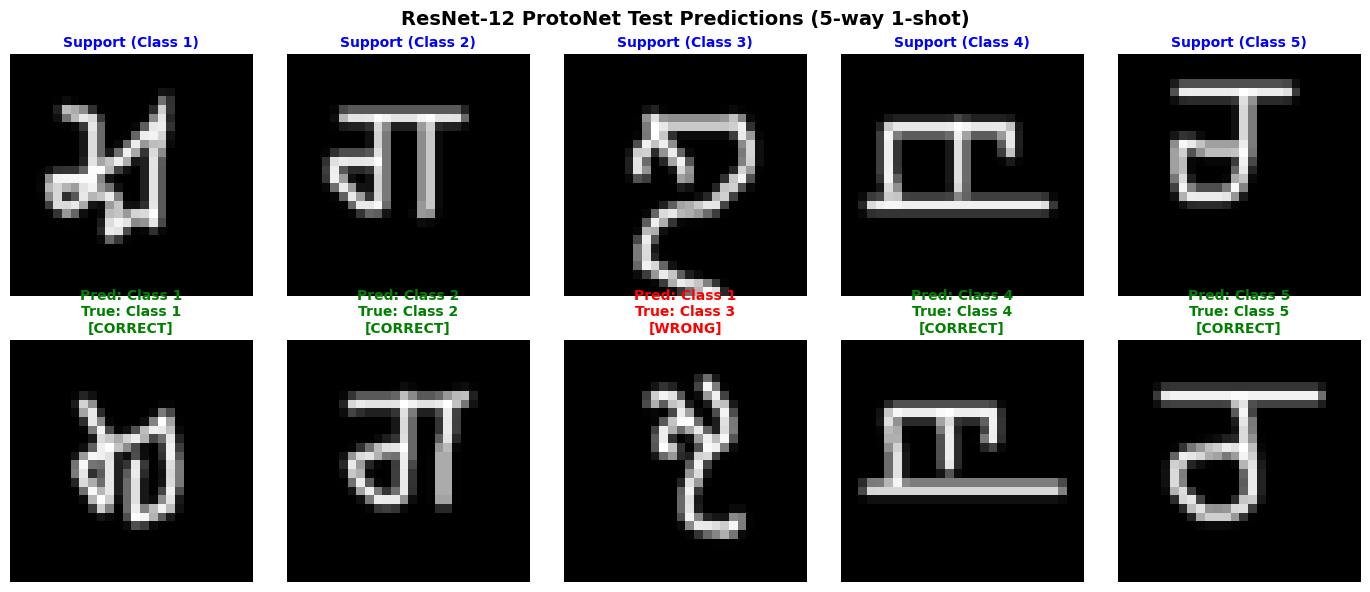

In [ ]:
import matplotlib.pyplot as plt

def plot_test_episode_predictions(model, dataset, labels, n_way=5, k_shot=1, q_query=1, device='cuda'):

    model.eval()

    classes = np.unique(labels)
    sampled_classes = np.random.choice(classes, n_way, replace=False)

    support_imgs, query_imgs, true_labels = [], [], []

    for class_idx, c in enumerate(sampled_classes):
        indices = np.where(labels == c)[0]
        selected = np.random.choice(indices, k_shot + q_query, replace=False)

        s_img, _ = dataset[selected[0]]
        support_imgs.append(s_img)

        for q_idx in range(1, k_shot + q_query):
            q_img, _ = dataset[selected[q_idx]]
            query_imgs.append(q_img)
            true_labels.append(class_idx)

    support_tensor = torch.stack(support_imgs).to(device)
    query_tensor = torch.stack(query_imgs).to(device)

    with torch.no_grad():
        s_emb = model(support_tensor)
        q_emb = model(query_tensor)

        dists = torch.cdist(q_emb, s_emb)
        preds = torch.argmin(dists, dim=1).cpu().numpy()

    fig, axes = plt.subplots(2, n_way, figsize=(14, 6))
    fig.suptitle("ResNet-12 ProtoNet Test Predictions (5-way 1-shot)", fontsize=14, fontweight='bold')

    for i in range(n_way):
        axes[0, i].imshow(support_imgs[i].squeeze(), cmap='gray')
        axes[0, i].set_title(f"Support (Class {i+1})", fontsize=10, color='blue', fontweight='bold')
        axes[0, i].axis('off')

        pred_c = preds[i]
        true_c = true_labels[i]
        is_correct = (pred_c == true_c)

        color = 'green' if is_correct else 'red'
        status = "CORRECT" if is_correct else "WRONG"

        axes[1, i].imshow(query_imgs[i].squeeze(), cmap='gray')
        axes[1, i].set_title(f"Pred: Class {pred_c+1}\nTrue: Class {true_c+1}\n[{status}]",
                            fontsize=10, color=color, fontweight='bold')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

plot_test_episode_predictions(model, test_dataset, test_labels, device=device)

In [19]:
def evaluate_with_confidence_interval(model, dataset, labels, n_way=5, k_shot=1, num_episodes=1000):
    model.eval()
    accs = []
    with torch.no_grad():
        for _ in range(num_episodes):
            episode_images = get_random_episode(dataset, labels, n_way, k_shot, q_query=5, device=device)
            _, acc = compute_proto_loss(model, episode_images, n_way, k_shot, q_query=5)
            accs.append(acc.item())

    mean_acc = np.mean(accs) * 100
    ci95 = 1.96 * (np.std(accs) * 100 / np.sqrt(num_episodes))
    print(f"Accuracy over {num_episodes} episodes ({n_way}-way {k_shot}-shot): {mean_acc:.2f}% +/- {ci95:.2f}%")

evaluate_with_confidence_interval(model, test_dataset, test_labels, n_way=5, k_shot=1)
evaluate_with_confidence_interval(model, test_dataset, test_labels, n_way=5, k_shot=5)

Accuracy over 1000 episodes (5-way 1-shot): 96.56% +/- 0.32%
Accuracy over 1000 episodes (5-way 5-shot): 99.17% +/- 0.13%


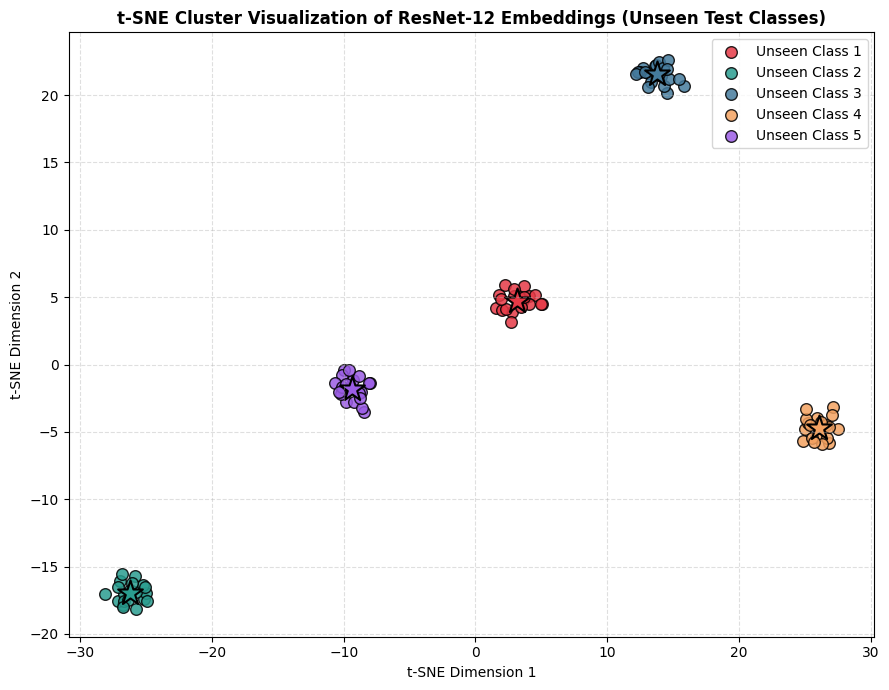

In [20]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize_tsne_unseen_classes(model, dataset, labels, n_way=5, samples_per_class=20, device='cuda'):

    model.eval()

    classes = np.unique(labels)
    sampled_classes = np.random.choice(classes, n_way, replace=False)

    features = []
    target_labels = []

    with torch.no_grad():
        for class_idx, c in enumerate(sampled_classes):
            indices = np.where(labels == c)[0]
            selected_indices = np.random.choice(indices, min(samples_per_class, len(indices)), replace=False)

            for idx in selected_indices:
                img, _ = dataset[idx]
                img = img.unsqueeze(0).to(device)
                feat = model(img)
                features.append(feat.cpu().numpy().squeeze())
                target_labels.append(class_idx)

    features = np.array(features)
    target_labels = np.array(target_labels)

    tsne = TSNE(n_components=2, perplexity=15, random_state=42)
    embeddings_2d = tsne.fit_transform(features)

    plt.figure(figsize=(9, 7))
    colors = ['#E63946', '#2A9D8F', '#457B9D', '#F4A261', '#9B5DE5']

    for class_idx in range(n_way):
        mask = target_labels == class_idx
        plt.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            color=colors[class_idx],
            label=f'Unseen Class {class_idx+1}',
            alpha=0.85,
            edgecolors='k',
            s=70
        )

        proto_2d = embeddings_2d[mask].mean(axis=0)
        plt.scatter(
            proto_2d[0],
            proto_2d[1],
            color=colors[class_idx],
            marker='*',
            s=350,
            edgecolors='black',
            linewidth=1.5
        )

    plt.title('t-SNE Cluster Visualization of ResNet-12 Embeddings (Unseen Test Classes)', fontsize=12, fontweight='bold')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

visualize_tsne_unseen_classes(model, test_dataset, test_labels, n_way=5, samples_per_class=20, device=device)